In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Loading the dataset (using ';' as the delimiter based on your file structure)
df = pd.read_csv('bank-full.csv', sep=';', engine='python', on_bad_lines='skip')

# Display the first few rows
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64


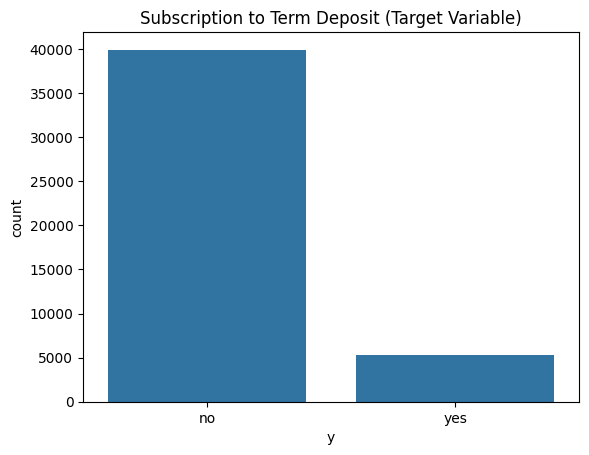

In [4]:
# Check for missing values
print(df.isnull().sum())

# Visualize the target variable distribution
sns.countplot(x='y', data=df)
plt.title('Subscription to Term Deposit (Target Variable)')
plt.show()

In [5]:
from sklearn.preprocessing import LabelEncoder

# Copying the dataframe for processing
df_encoded = df.copy()

# Encoding categorical variables
le = LabelEncoder()
categorical_cols = df.select_dtypes(include=['object']).columns

for col in categorical_cols:
    df_encoded[col] = le.fit_transform(df[col])

# Split into features (X) and target (y)
X = df_encoded.drop('y', axis=1)
y = df_encoded['y']

              precision    recall  f1-score   support

           0       0.90      0.98      0.94      7952
           1       0.57      0.22      0.32      1091

    accuracy                           0.89      9043
   macro avg       0.74      0.60      0.63      9043
weighted avg       0.86      0.89      0.86      9043



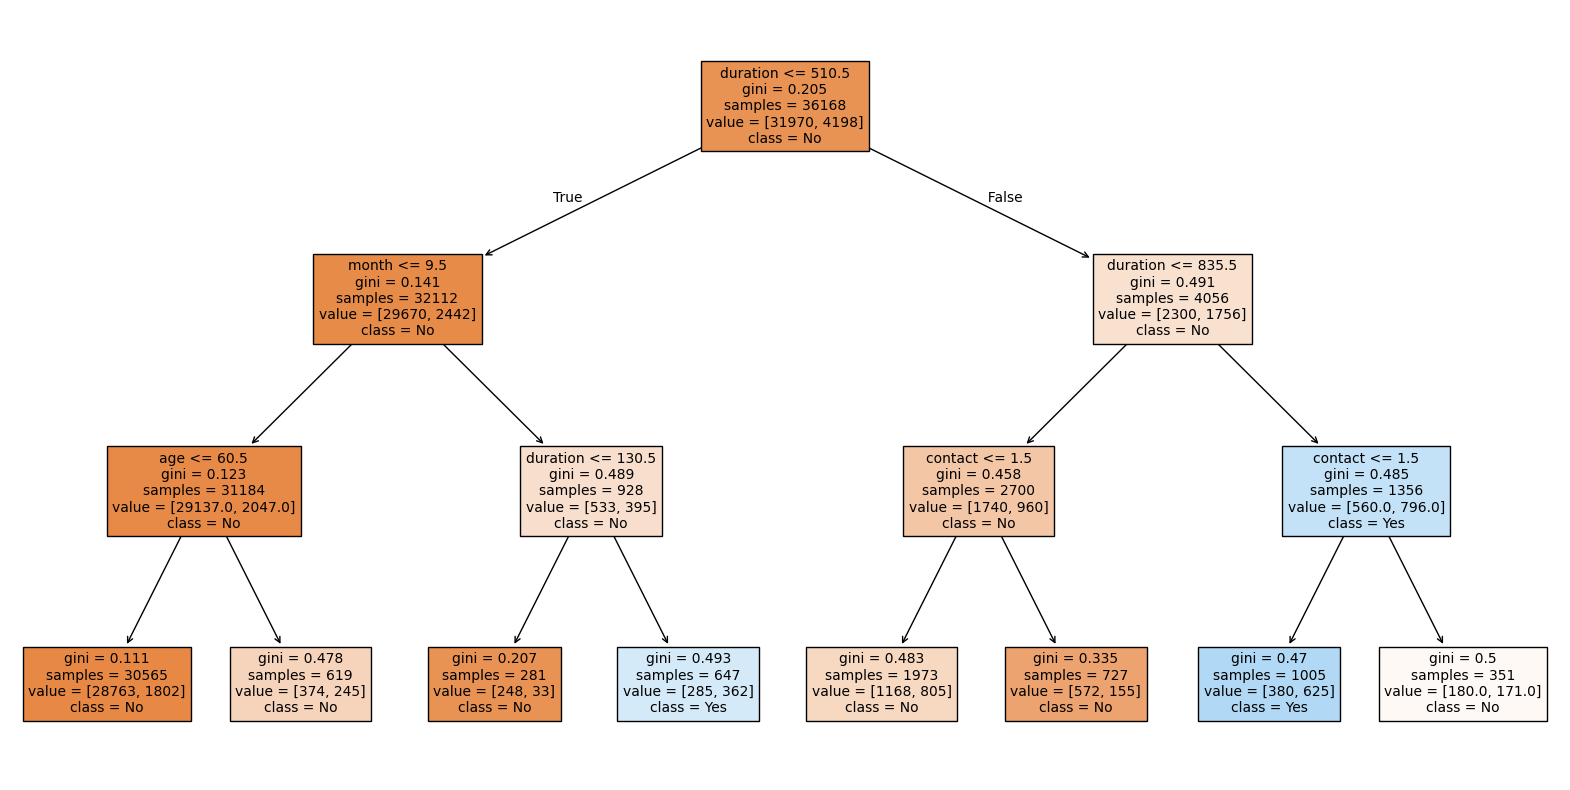

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import classification_report

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and train the model
clf = DecisionTreeClassifier(max_depth=3) # Depth limited for visibility
clf.fit(X_train, y_train)

# Predictions
y_pred = clf.predict(X_test)

print(classification_report(y_test, y_pred))


plt.figure(figsize=(20,10))
plot_tree(clf, feature_names=X.columns, class_names=['No', 'Yes'], filled=True)
plt.show()